In [1]:
from POSEIDON.core import create_star, create_planet, wl_grid_constant_R
from POSEIDON.constants import R_Sun, R_J, M_J

import numpy as np
import scipy.constants as sc

#***** Define stellar properties *****#

R_s = 1.49*R_Sun     # Stellar radius (m)
T_s = 6550           # Stellar effective temperature (K)
Met_s = -0.25        # Stellar metallicity [log10(Fe/H_star / Fe/H_solar)]
log_g_s = 4.2        # Stellar log surface gravity (log10(cm/s^2) by convention)

# Create the stellar object
star = create_star(R_s, T_s, log_g_s, Met_s)

#***** Define planet properties *****#

planet_name = 'WASP-17b'  # Planet name used for plots, output files etc.

R_p = 1.87*R_J                    # Planetary radius (m)
M_p = 0.78*M_J                    # Planetary mass (kg)
g_p = (sc.G*M_p)/(R_p**2)         # Gravitational field of planet (m/s^2)
T_eq = 1447                       # Equilibrium temperature (K)

# Create the planet object
planet = create_planet(planet_name, R_p, gravity = g_p, T_eq = T_eq)

# Initialise wavelength grid
wl_min = 0.2      # Minimum wavelength (um)
wl_max = 13.0     # Maximum wavelength (um)
R = 10000         # Spectral resolution of grid (R = wl/dwl)

wl = wl_grid_constant_R(wl_min, wl_max, R)

# Specify the pressure grid of the atmosphere
P_min = 1.0e-7    # 0.1 ubar
P_max = 100       # 100 bar
N_layers = 100    # 100 layers

# We'll space the layers uniformly in log-pressure
P = np.logspace(np.log10(P_max), np.log10(P_min), N_layers)

# Specify the reference pressure and radius
P_ref = 1.0e-2    # Reference pressure (bar)
R_p_ref = R_p     # Radius at reference pressure

/home/ers1n25/miniconda3/envs/poseidon/lib/python3.11/site-packages/pysynphot/__init__.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [2]:
from POSEIDON.core import define_model

model_name = 'My_First_Cloudy_Atmosphere'

bulk_species = ['H2','He']
param_species = ['H2O']

model_deck_haze = define_model(model_name,bulk_species,param_species,
                               PT_profile = 'isotherm', X_profile = 'isochem',
                               cloud_model = 'MacMad17', # <---- Put cloud model here
                               cloud_type = 'deck_haze', # <---- Put cloud type here
                               cloud_dim = 1,            # <---- Put cloud dimension here
                               )

print("PT parameters : " + str(model_deck_haze['PT_param_names']))
print("X parameters : " + str(model_deck_haze['X_param_names']))
print("Cloud parameters : " + str(model_deck_haze['cloud_param_names'])) # <---- Let's print out the cloud parameters

PT parameters : ['T']
X parameters : ['log_H2O']
Cloud parameters : ['log_a' 'gamma' 'log_P_cloud']


In [3]:
from POSEIDON.core import make_atmosphere

# PT and X parameters
T = 1200             # Temperature
log_H2O = -4         # H2O mixing ratio

# Cloud Parameters
log_a       = 1.7 # <---- Rayleigh enhancement factor of the power-law haze
gamma       = -8  # <---- Scattering slope of the power-law haze
log_P_cloud = -2  # <---- log-pressure of the top of the infinite opacity deck (bar)

PT_params = np.array([T])
log_X_params = np.array([log_H2O])
cloud_params = np.array([log_a, gamma, log_P_cloud])

# Make atmosphere
atmosphere_deck_haze = make_atmosphere(planet, model_deck_haze, P, P_ref, R_p_ref, PT_params, log_X_params, cloud_params)

In [4]:
from POSEIDON.core import read_opacities

#***** Read opacity data *****#

opacity_treatment = 'opacity_sampling'

# First, specify limits of the fine temperature and pressure grids for the
# pre-interpolation of cross sections. These fine grids should cover a
# wide range of possible temperatures and pressures for the model atmosphere.

# Define fine temperature grid (K)
T_fine_min = 400     # 400 K lower limit suffices for a typical hot Jupiter
T_fine_max = 2000    # 2000 K upper limit suffices for a typical hot Jupiter
T_fine_step = 10     # 10 K steps are a good tradeoff between accuracy and RAM

T_fine = np.arange(T_fine_min, (T_fine_max + T_fine_step), T_fine_step)

# Define fine pressure grid (log10(P/bar))
log_P_fine_min = -6.0   # 1 ubar is the lowest pressure in the opacity database
log_P_fine_max = 2.0    # 100 bar is the highest pressure in the opacity database
log_P_fine_step = 0.2   # 0.2 dex steps are a good tradeoff between accuracy and RAM

log_P_fine = np.arange(log_P_fine_min, (log_P_fine_max + log_P_fine_step),
                       log_P_fine_step)

# Now we can pre-interpolate the sampled opacities (may take up to a minute)
opac = read_opacities(model_deck_haze, wl, opacity_treatment, T_fine, log_P_fine)

Reading in cross sections in opacity sampling mode...
H2-H2 done
H2-He done
H2O done
Opacity pre-interpolation complete.


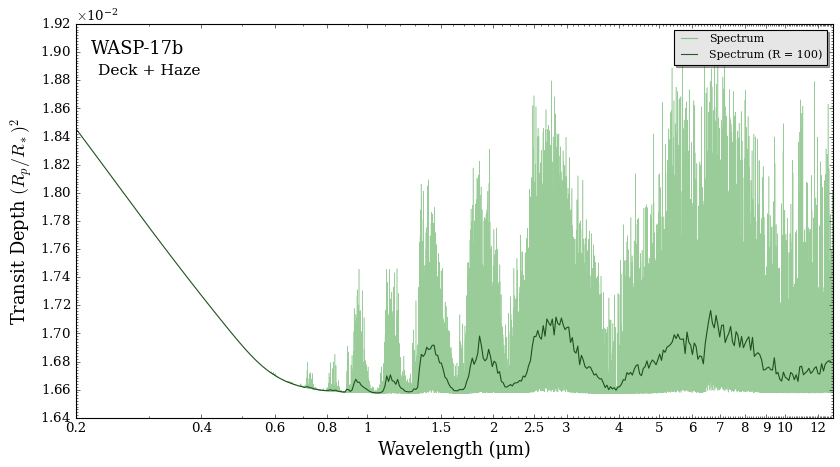

In [5]:
from POSEIDON.core import compute_spectrum
from POSEIDON.visuals import plot_spectra
from POSEIDON.utility import plot_collection

# Generate spectrum
spectrum_deck_haze = compute_spectrum(planet, star, model_deck_haze,
                                      atmosphere_deck_haze, opac, wl,
                                      spectrum_type = 'transmission')
# Plot spectrum
spectra = plot_collection(spectrum_deck_haze, wl, collection = [])

fig = plot_spectra(spectra, planet, R_to_bin = 100,
                   plt_label = 'Deck + Haze', save_fig = False,
                   figure_shape = 'wide')

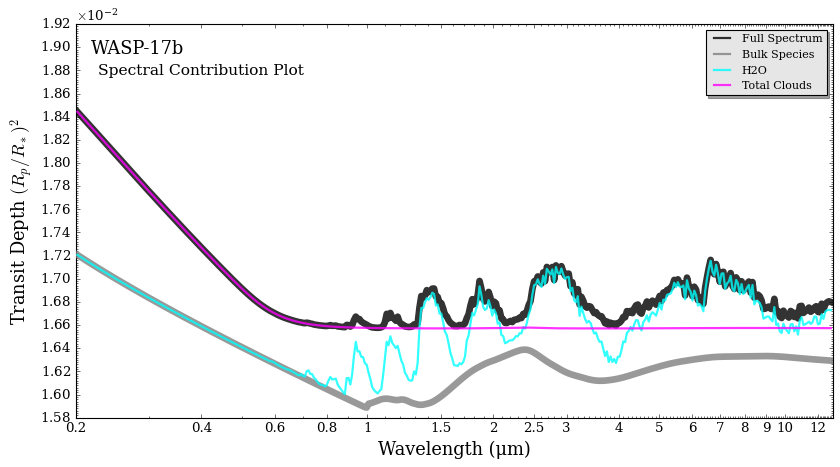

In [6]:
from POSEIDON.contributions import spectral_contribution, plot_spectral_contribution

spectrum, spectrum_contribution_list_names, \
spectrum_contribution_list = spectral_contribution(planet, star, model_deck_haze,
                                                   atmosphere_deck_haze, opac, wl,
                                                   contribution_species_list = ['H2O'],
                                                   bulk_species = True,
                                                   cloud_contribution = True,
                                                   )

fig = plot_spectral_contribution(planet, wl, spectrum, spectrum_contribution_list_names,
                                 spectrum_contribution_list, return_fig = True,
                                 line_width_list = [6,6,2,2],
                                 colour_list = ['black', 'gray', 'cyan','magenta'],
                                 figure_shape = 'wide')

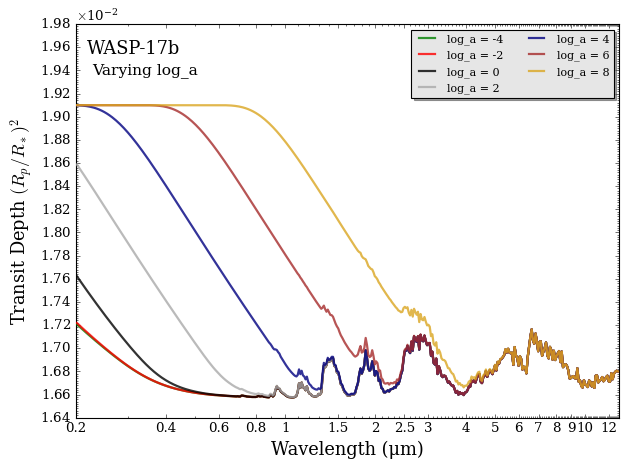

In [7]:
from POSEIDON.clouds import vary_one_parameter

param_name = 'log_a'
vary_list = [-4,-2,0,2,4,6,8]

vary_one_parameter(model_deck_haze, planet, star, param_name, vary_list, wl, opac,
                   P, P_ref, R_p_ref, PT_params, log_X_params, cloud_params,
                   y_min = 1.64e-2, y_max = 1.98e-2,
                   )

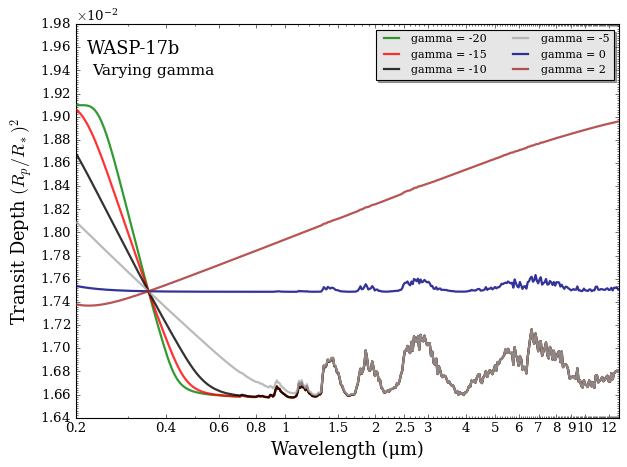

In [8]:
param_name = 'gamma'
vary_list = [-20,-15,-10,-5,0,2]

vary_one_parameter(model_deck_haze, planet, star, param_name, vary_list, wl, opac,
                   P, P_ref, R_p_ref, PT_params, log_X_params, cloud_params,
                   y_min = 1.64e-2, y_max = 1.98e-2,
                   )

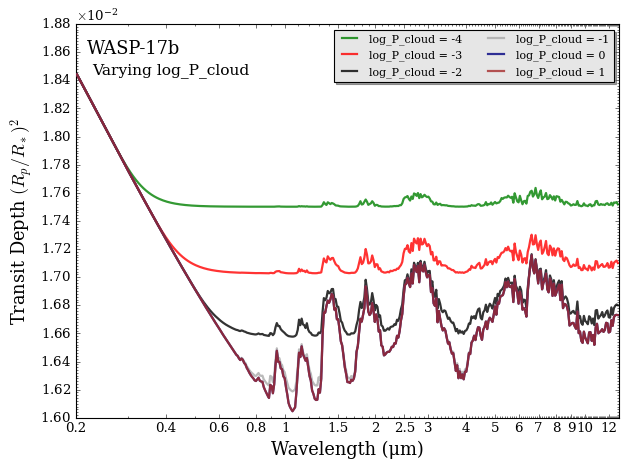

In [9]:
param_name = 'log_P_cloud'
vary_list = [-4,-3,-2,-1,0,1]

vary_one_parameter(model_deck_haze, planet, star, param_name, vary_list, wl, opac,
                   P, P_ref, R_p_ref, PT_params, log_X_params, cloud_params,
                   y_min = 1.60e-2, y_max = 1.88e-2,
                   )

In [10]:
from POSEIDON.supported_chemicals import aerosol_supported_species

print(aerosol_supported_species)

['ADP' 'Al2O3' 'Al2O3_KH' 'C' 'CH4_liquid' 'CH4_solid' 'CaTiO3'
 'CaTiO3_KH' 'Cr' 'ExoHaze_1000xSolar_300K' 'ExoHaze_1000xSolar_400K' 'Fe'
 'Fe2O3' 'Fe2SiO4_KH' 'FeO' 'FeS' 'FeSiO3' 'H2O' 'H2O_ice' 'H2SO4'
 'Hexene' 'Hibonite' 'IceTholin' 'KCl' 'Mg2SiO4_amorph_sol_gel'
 'Mg2SiO4_amorph' 'Mg2SiO4_Fe_poor' 'Mg2SiO4_Fe_rich'
 'Mg2SiO4_crystalline' 'Mg4Fe6SiO3_amorph_glass' 'Mg5Fe5SiO3_amorph_glass'
 'Mg8Fe12SiO4_amorph_glass' 'Mg8Fe2SiO3_amorph_glass' 'MgAl2O4'
 'MgFeSiO4_amorph_glass' 'MgO' 'MgSiO3' 'MgSiO3_amorph'
 'MgSiO3_crystalline' 'MgSiO3_amorph_glass' 'MgSiO3_sol_gel' 'MnS'
 'MnS_KH' 'MnS_Mor' 'Na2S' 'NaCl' 'NanoDiamonds' 'NH3' 'NH4SH' 'S8'
 'Saturn-Phosphorus-Haze' 'SiC' 'SiO' 'SiO2' 'SiO2_amorph'
 'SiO2_crystalline_2023' 'SiO2_alpha_palik' 'SiO2_glass_palik' 'Soot'
 'Soot_6mm' 'Tholin' 'Tholin-CO-0625' 'Tholin-CO-1' 'TiC' 'TiO2_anatase'
 'TiO2_rutile' 'VO' 'ZnS']


In [11]:
from POSEIDON.clouds import load_aerosol_grid, interpolate_sigma_Mie_grid

species = 'SiO2'

# Load in the aerosol grid
aerosol_grid = load_aerosol_grid([species])

# Specify mean radius of the aerosol particles
r_m = 0.01

# Loads effective extinction cross section
sigma_Mie_interp_array = interpolate_sigma_Mie_grid(aerosol_grid, wl, [r_m], [species],)

# Extract the cross sections, asymmetry parameter, and single scattering albedo
eff_ext = sigma_Mie_interp_array[species]['eff_ext']
eff_w = sigma_Mie_interp_array[species]['eff_w']
eff_g = sigma_Mie_interp_array[species]['eff_g']

Reading in database for aerosol cross sections...
/home/ers1n25/POSEIDON/inputs


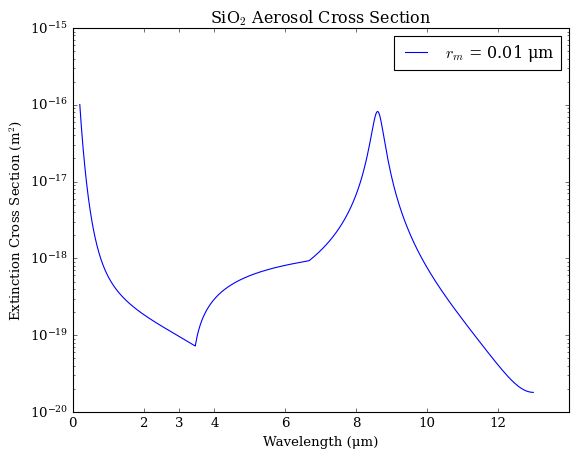

In [12]:
import matplotlib.pyplot as plt

label = '$r_m$ = ' + str(r_m) + ' μm'
title = 'SiO$_2$ Aerosol Cross Section'

plt.semilogy(wl, eff_ext, label = label)
plt.legend()
plt.title(title)
plt.xlabel('Wavelength (μm)')
plt.ylabel('Extinction Cross Section (m$^2$)')
plt.xticks((0,2,3,4,6,8,10,12))
plt.show()

Loading in :  ./POSEIDON/reference_data/refractive_indices_txt_files/aerosol_database/WS15/H2O_complex.txt


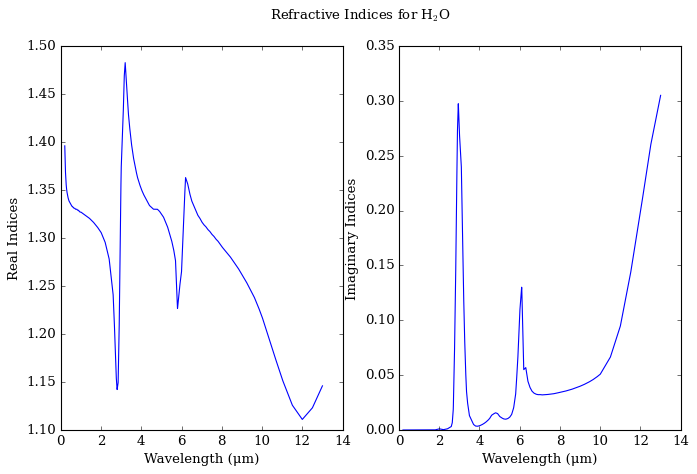

<Figure size 640x480 with 0 Axes>

In [15]:
from POSEIDON.clouds import plot_refractive_indices_from_file

# Load H2O refractive index file
refractive_index_path = './POSEIDON/reference_data/refractive_indices_txt_files/aerosol_database/WS15/'
file_name = refractive_index_path + 'H2O_complex.txt'

# Plot the refractive index
plot_refractive_indices_from_file(wl, file_name, species = 'H$_2$O')

Loading in :  ./POSEIDON/reference_data/refractive_indices_txt_files/aerosol_database/WS15/H2O_complex.txt


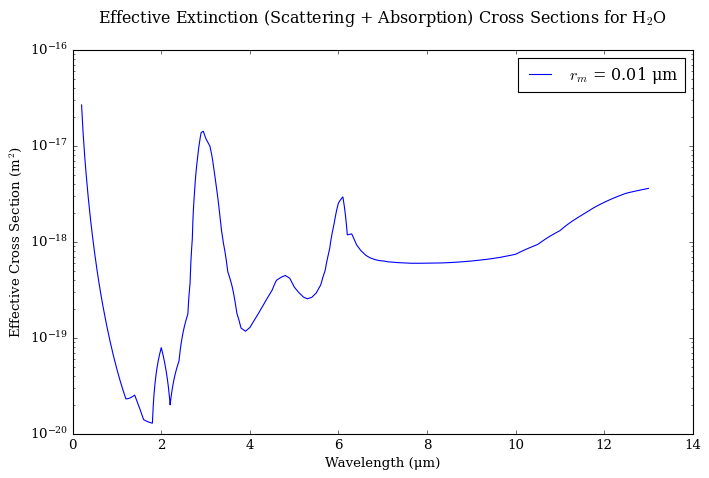

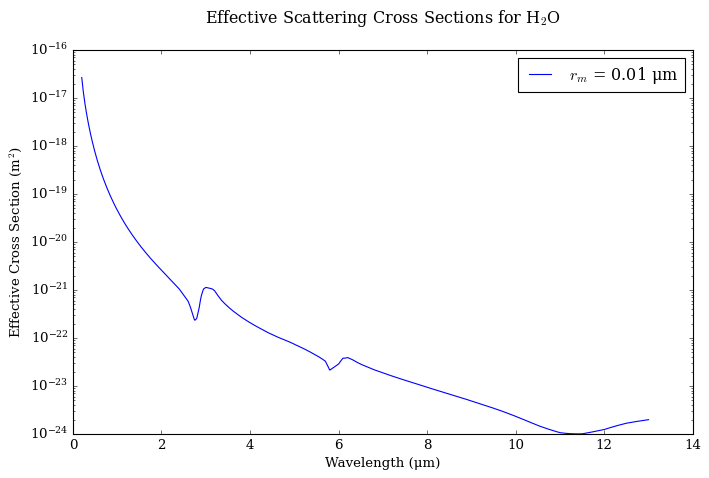

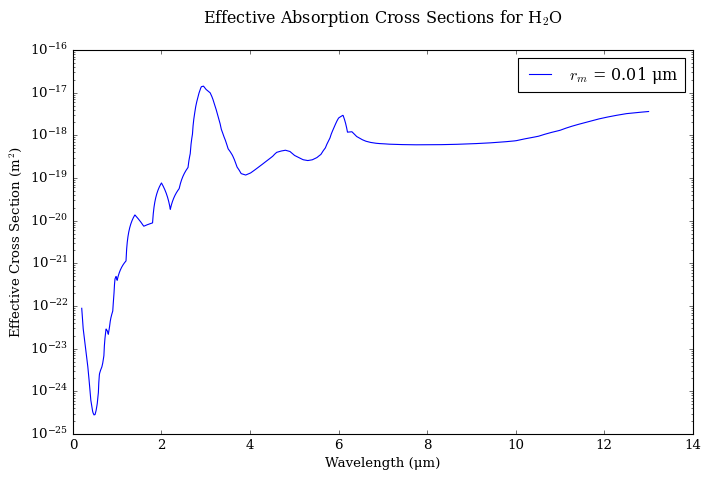

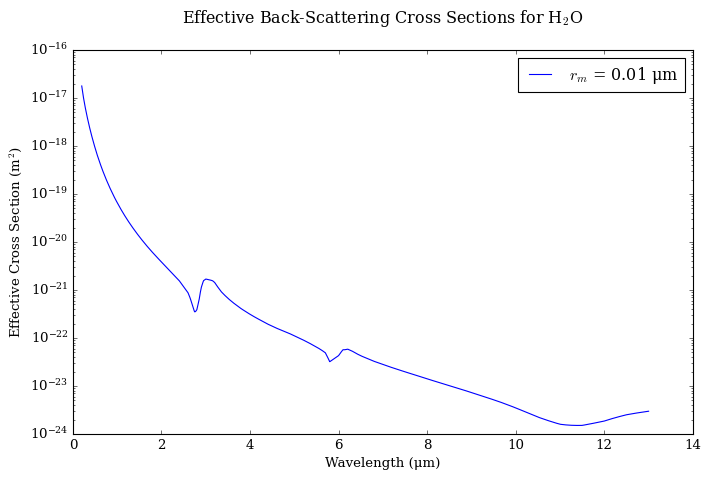

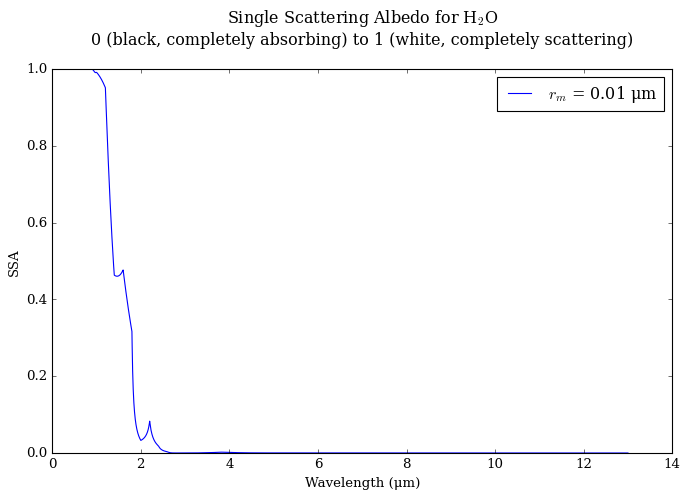

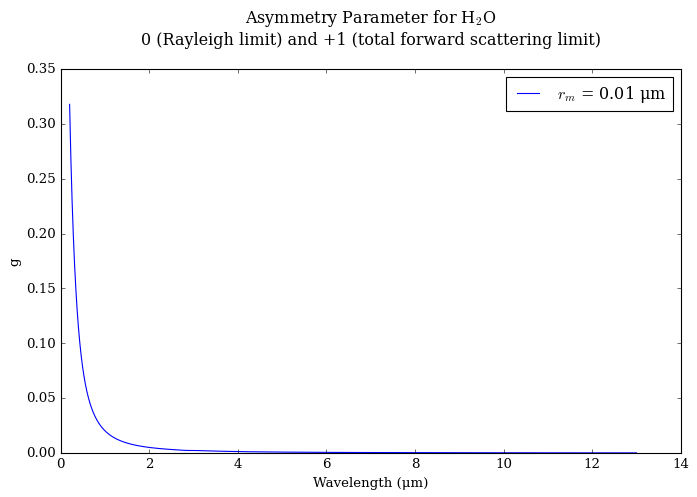

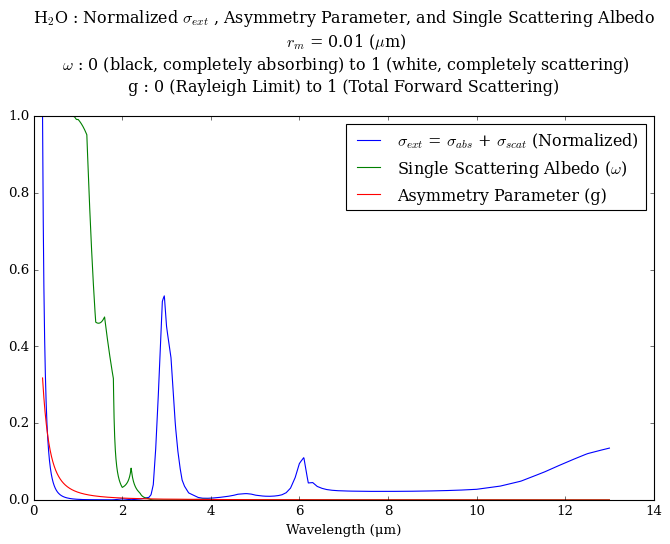

In [16]:
from POSEIDON.clouds import compute_and_plot_aerosol_cross_section_from_file

# Mean particle size
r_m = 0.01

# Run the Mie scattering calculation
compute_and_plot_aerosol_cross_section_from_file(wl, r_m, file_name, species = 'H$_2$O')

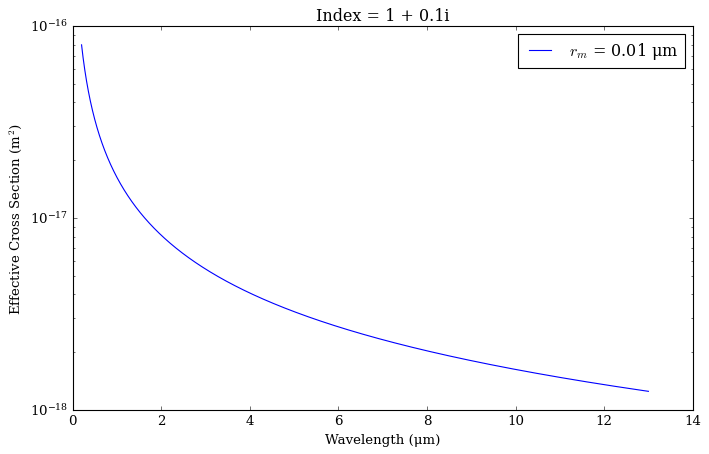

In [17]:
from POSEIDON.clouds import compute_and_plot_effective_cross_section_constant

# Mean particle size
r_m = 0.01

# Real and imaginary parts of the refractive index
ref_index_real = 1
ref_index_imaginary = 0.1

compute_and_plot_effective_cross_section_constant(wl, r_m, ref_index_real, ref_index_imaginary)

In [18]:
from POSEIDON.core import define_model

#***** Define model *****#

model_name = 'Fuzzy_Deck_SiO2'

bulk_species = ['H2', 'He']
param_species = ['H2O']

# Set aerosol species
aerosol_species = ['SiO2']  # <---- Put aerosol species here

# Define model
model_fuzzy_deck = define_model(model_name, bulk_species, param_species,
                                PT_profile = 'isotherm', X_profile = 'isochem',
                                cloud_model = 'Mie',                 # <---- Put cloud model here (Mie)
                                cloud_type = 'fuzzy_deck',           # <---- Put cloud type here
                                aerosol_species = aerosol_species,   # <---- Put aerosol species list here
                                )


# Check the free parameters defining this model
print("PT parameters : " + str(model_fuzzy_deck['PT_param_names']))
print("X parameters : " + str(model_fuzzy_deck['X_param_names']))
print("Cloud parameters : " + str(model_fuzzy_deck['cloud_param_names'])) # <---- Print the cloud param names

PT parameters : ['T']
X parameters : ['log_H2O']
Cloud parameters : ['log_P_top_deck_SiO2' 'log_r_m_SiO2' 'log_n_max_SiO2' 'f_SiO2']


In [19]:
from POSEIDON.core import make_atmosphere

# PT and X parameters
T = 1200
log_H2O = -4

# Cloud Parameters
log_P_top_deck_SiO2 = 0     # <---- Top of the opaque deck is at 1 bar (extends from 100 to 1 bar)
log_r_m_SiO2        = -2    # <---- Mean particle size of the SiO2 aerosols is 1e-2 microns
log_n_max_SiO2      = 20    # <---- The number density of SiO2 at the top of the opaque deck (at 1 bar)
f_SiO2              = 0.3   # <---- The fuzziness of aerosols (how number density evolves above the cloud deck)

PT_params = np.array([T])
log_X_params = np.array([log_H2O])
cloud_params = np.array([log_P_top_deck_SiO2, log_r_m_SiO2, log_n_max_SiO2, f_SiO2])

# Make atmosphere
atmosphere_fuzzy_deck = make_atmosphere(planet, model_fuzzy_deck, P, P_ref, R_p_ref,
                                        PT_params, log_X_params, cloud_params)

In [20]:
from POSEIDON.core import read_opacities

#***** Read opacity data *****#

opacity_treatment = 'opacity_sampling'

# First, specify limits of the fine temperature and pressure grids for the
# pre-interpolation of cross sections. These fine grids should cover a
# wide range of possible temperatures and pressures for the model atmosphere.

# Define fine temperature grid (K)
T_fine_min = 400     # 400 K lower limit suffices for a typical hot Jupiter
T_fine_max = 2000    # 2000 K upper limit suffices for a typical hot Jupiter
T_fine_step = 10     # 10 K steps are a good tradeoff between accuracy and RAM

T_fine = np.arange(T_fine_min, (T_fine_max + T_fine_step), T_fine_step)

# Define fine pressure grid (log10(P/bar))
log_P_fine_min = -6.0   # 1 ubar is the lowest pressure in the opacity database
log_P_fine_max = 2.0    # 100 bar is the highest pressure in the opacity database
log_P_fine_step = 0.2   # 0.2 dex steps are a good tradeoff between accuracy and RAM

log_P_fine = np.arange(log_P_fine_min, (log_P_fine_max + log_P_fine_step),
                       log_P_fine_step)

# Now we can pre-interpolate the sampled opacities (may take up to a minute)
opac_sio2 = read_opacities(model_fuzzy_deck, wl, opacity_treatment, T_fine, log_P_fine)

Reading in cross sections in opacity sampling mode...
H2-H2 done
H2-He done
H2O done
Reading in database for aerosol cross sections...
/home/ers1n25/POSEIDON/inputs
Opacity pre-interpolation complete.


In [21]:
from POSEIDON.clouds import switch_aerosol_in_opac

opac_sio2 = switch_aerosol_in_opac(model_fuzzy_deck,opac)

Reading in database for aerosol cross sections...
/home/ers1n25/POSEIDON/inputs


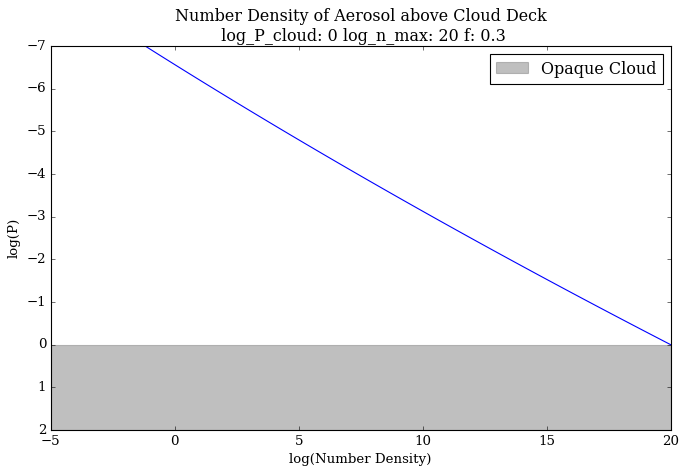

Max mixing ratio :  -4.7807354712741414
Min mixing ratio :  -18.970141150086874


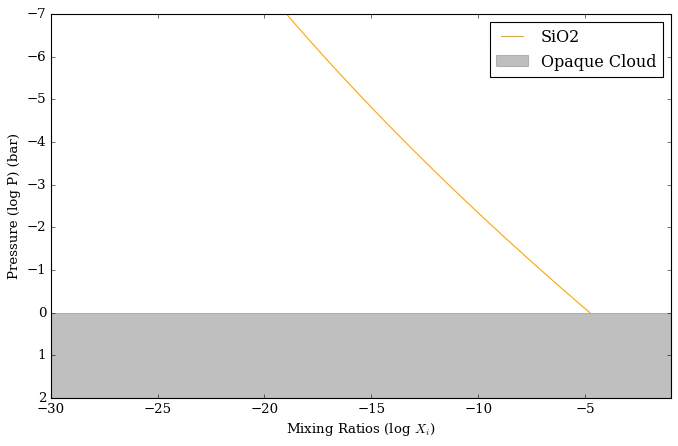

In [22]:
from POSEIDON.clouds import plot_aerosol_number_density_fuzzy_deck, plot_clouds

# Plot the aerosol number density profile
plot_aerosol_number_density_fuzzy_deck(atmosphere_fuzzy_deck,log_P_top_deck_SiO2,log_n_max_SiO2,f_SiO2)

# Plot the aerosol mixing ratio profile
plot_clouds(planet,model_fuzzy_deck,atmosphere_fuzzy_deck)

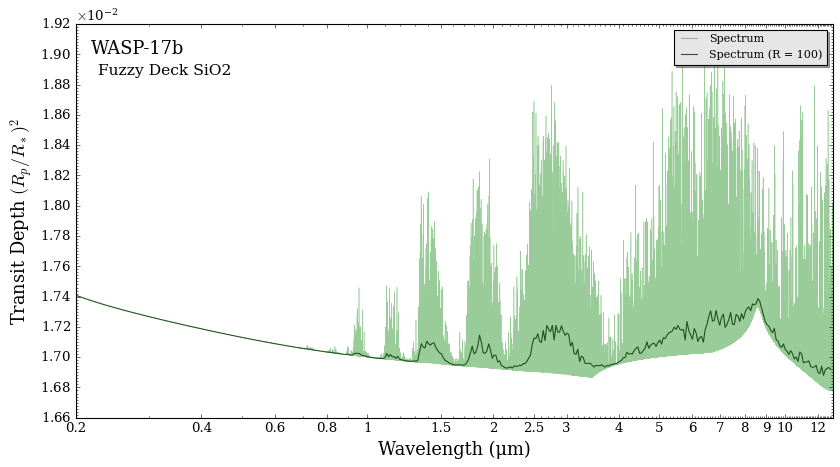

In [23]:
from POSEIDON.core import compute_spectrum
from POSEIDON.visuals import plot_spectra
from POSEIDON.utility import plot_collection

# Generate spectrum
spectrum_fuzzy_deck = compute_spectrum(planet, star, model_fuzzy_deck,
                                       atmosphere_fuzzy_deck, opac_sio2, wl, #<- Make sure to use opac with SiO2 in it
                                       spectrum_type = 'transmission')
# Plot spectrum
spectra = plot_collection(spectrum_fuzzy_deck, wl, collection = [])

fig = plot_spectra(spectra, planet, R_to_bin = 100,
                   plt_label = 'Fuzzy Deck SiO2',
                   save_fig = False,
                   figure_shape = 'wide',
                   )

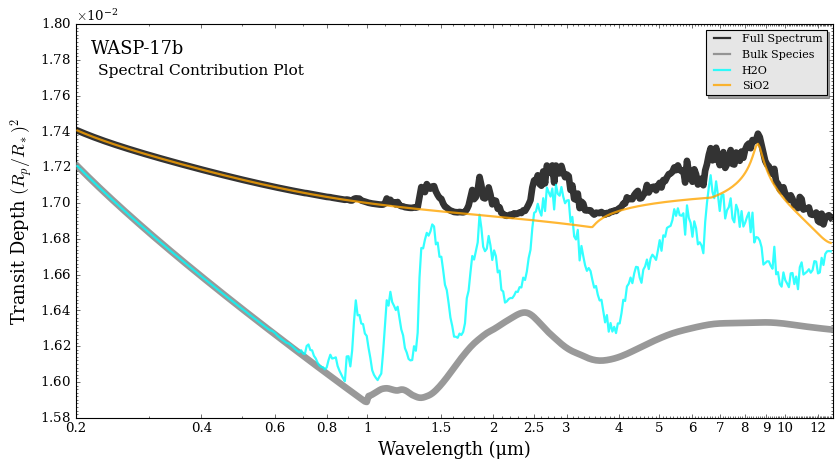

In [24]:
from POSEIDON.contributions import spectral_contribution, plot_spectral_contribution

spectrum, spectrum_contribution_list_names, \
spectrum_contribution_list = spectral_contribution(planet, star, model_fuzzy_deck,
                                                   atmosphere_fuzzy_deck, opac_sio2, wl,
                                                   contribution_species_list = ['H2O'],
                                                   cloud_species_list = ['SiO2'],
                                                   bulk_species = True,
                                                   cloud_contribution = True,
                                                   )

fig = plot_spectral_contribution(planet, wl, spectrum, spectrum_contribution_list_names,
                                 spectrum_contribution_list,
                                 return_fig = True,
                                 line_width_list = [6,6,2,2],
                                 colour_list = ['black', 'gray', 'cyan', 'orange'],
                                 y_min = 1.58e-2, y_max = 1.80e-2,
                                 )

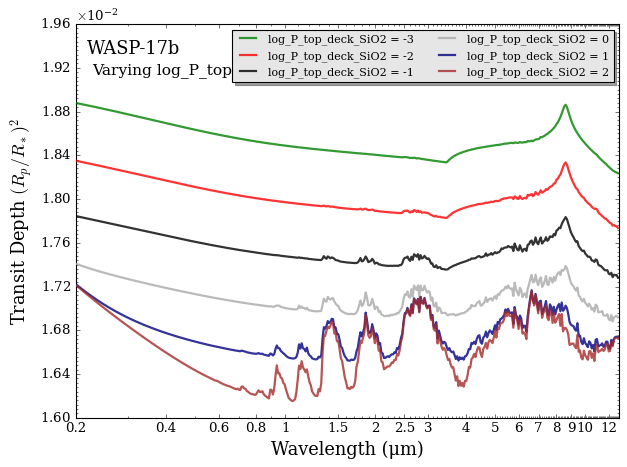

In [25]:
param_name = 'log_P_top_deck_SiO2'
vary_list = [-3,-2,-1,0,1,2]

vary_one_parameter(model_fuzzy_deck, planet, star, param_name, vary_list, wl, opac_sio2,
                   P, P_ref, R_p_ref, PT_params, log_X_params, cloud_params,
                   y_min = 1.60e-2, y_max = 1.96e-2,
                   )

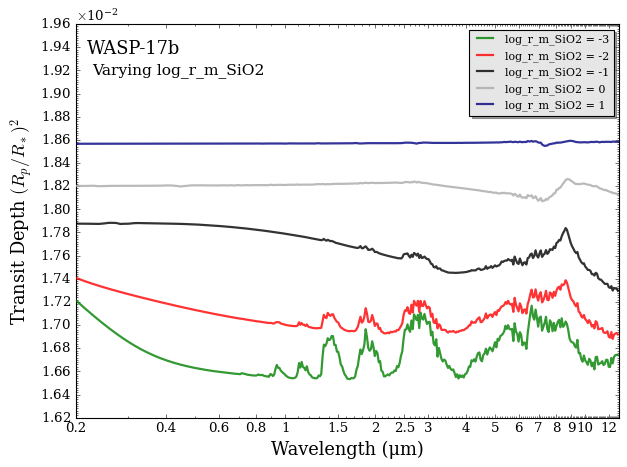

In [26]:
param_name = 'log_r_m_SiO2'
vary_list = [-3,-2,-1,0,1]

vary_one_parameter(model_fuzzy_deck, planet, star, param_name, vary_list, wl, opac_sio2,
                   P, P_ref, R_p_ref, PT_params, log_X_params, cloud_params,
                   y_min = 1.62e-2, y_max = 1.96e-2,
                   )

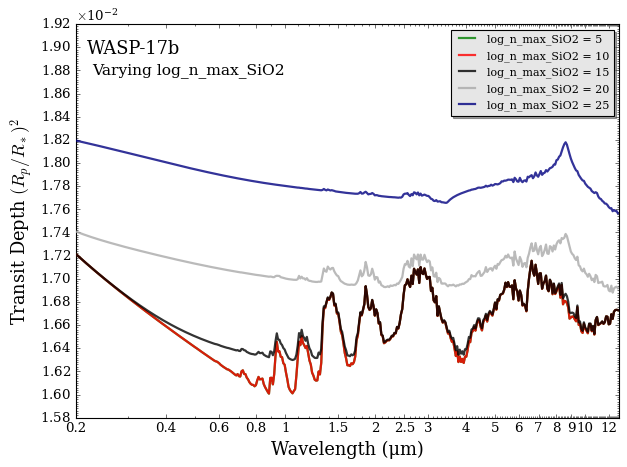

In [27]:
param_name = 'log_n_max_SiO2'
vary_list = [5,10,15,20,25]

vary_one_parameter(model_fuzzy_deck, planet, star, param_name, vary_list, wl, opac_sio2,
                   P, P_ref, R_p_ref, PT_params, log_X_params, cloud_params,
                   y_min = 1.58e-2, y_max = 1.92e-2,
                   )

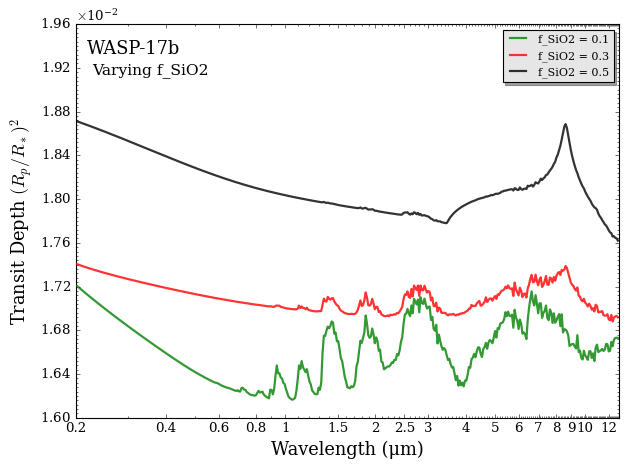

In [28]:
param_name = 'f_SiO2'
vary_list = [0.1,0.3, 0.5]

vary_one_parameter(model_fuzzy_deck, planet, star, param_name, vary_list, wl, opac_sio2,
                   P, P_ref, R_p_ref, PT_params, log_X_params, cloud_params,
                   y_min = 1.60e-2, y_max = 1.96e-2,
                   )

In [29]:
from POSEIDON.core import define_model

#***** Define model *****#

model_name = 'Slab_SiO2'

bulk_species = ['H2', 'He']      # H2 + He comprises the bulk atmosphere
param_species = ['H2O']
aerosol_species = ['SiO2']

model_slab = define_model(model_name, bulk_species, param_species,
                     PT_profile = 'isotherm', X_profile = 'isochem',
                     cloud_model = 'Mie',               # <---- Put cloud model here (Mie)
                     cloud_type = 'slab',               # <---- Put cloud type here
                     aerosol_species = aerosol_species) # <---- Put aerosol species list here


# Check the free parameters defining this model
print("PT parameters : " + str(model_slab['PT_param_names']))
print("X parameters : " + str(model_slab['X_param_names']))
print("Cloud parameters : " + str(model_slab['cloud_param_names']))  # <---- Print the cloud param names

PT parameters : ['T']
X parameters : ['log_H2O']
Cloud parameters : ['log_P_top_slab_SiO2' 'Delta_log_P_SiO2' 'log_r_m_SiO2' 'log_X_SiO2']


In [30]:
from POSEIDON.core import make_atmosphere

# PT and X parameters
T = 1200
log_H2O = -4

# Cloud Parameters
log_P_top_slab_SiO2 = -5  # <---- The top of the slab in pressure space (at 1e-5 bars)
Delta_log_P_SiO2    = 2   # <---- Extend of the slab in pressure space (extends down to 1e-3 bars)
log_r_m_SiO2        = -2  # <---- Mean particle size of the SiO2 aerosols is 1e-2 microns
log_X_SiO2          = -12 # <---- Volume mixing ratio of aerosol in the slab (1e-5 to 1e-3 bars)

PT_params = np.array([T])
log_X_params = np.array([log_H2O])
cloud_params = ([log_P_top_slab_SiO2,Delta_log_P_SiO2,log_r_m_SiO2,log_X_SiO2])

# Make atmosphere
atmosphere_slab = make_atmosphere(planet, model_slab, P, P_ref, R_p_ref, PT_params, log_X_params, cloud_params)

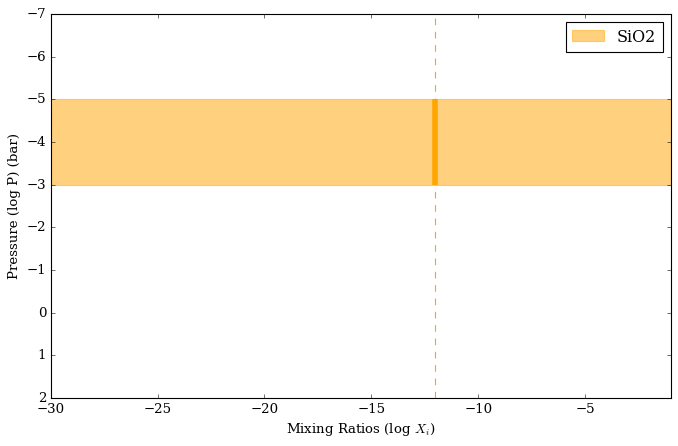

In [31]:
from POSEIDON.clouds import plot_clouds

plot_clouds(planet,model_slab,atmosphere_slab)

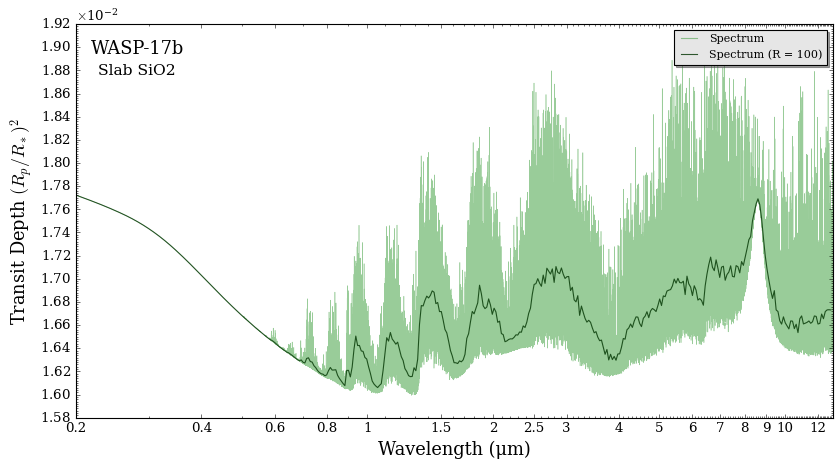

In [32]:
from POSEIDON.core import compute_spectrum
from POSEIDON.visuals import plot_spectra
from POSEIDON.utility import plot_collection

# Generate spectrum
spectrum_slab = compute_spectrum(planet, star, model_slab, atmosphere_slab, opac_sio2, wl,
                                      spectrum_type = 'transmission')
# Plot spectrum
spectra = plot_collection(spectrum_slab, wl, collection = [])

fig = plot_spectra(spectra, planet, R_to_bin = 100,
                   plt_label = 'Slab SiO2',
                   save_fig = False,
                   figure_shape = 'wide')

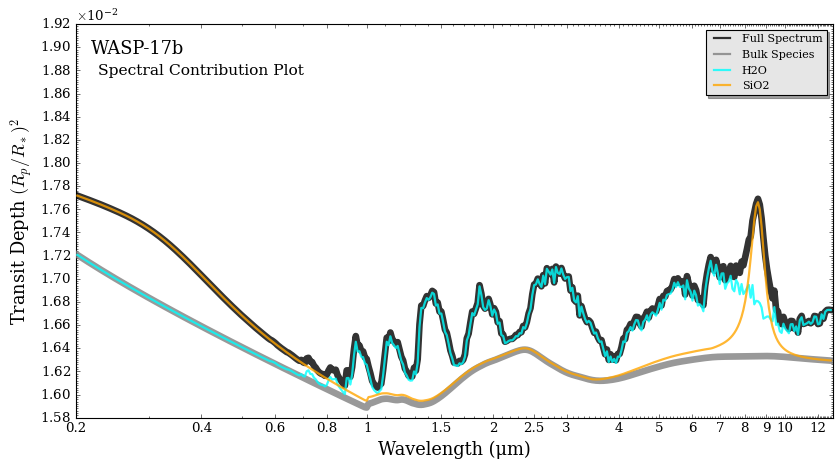

In [33]:
from POSEIDON.contributions import spectral_contribution, plot_spectral_contribution

spectrum, spectrum_contribution_list_names, spectrum_contribution_list = spectral_contribution(planet, star,  model_slab, atmosphere_slab, opac_sio2, wl,
                                                                                               contribution_species_list = ['H2O'],
                                                                                               cloud_species_list = ['SiO2'],
                                                                                               bulk_species = True,
                                                                                               cloud_contribution = True,)

fig = plot_spectral_contribution(planet, wl, spectrum, spectrum_contribution_list_names, spectrum_contribution_list,
                                 return_fig = True,
                                 line_width_list = [6,6,2,2],
                                 colour_list = ['black', 'gray', 'cyan', 'orange'])

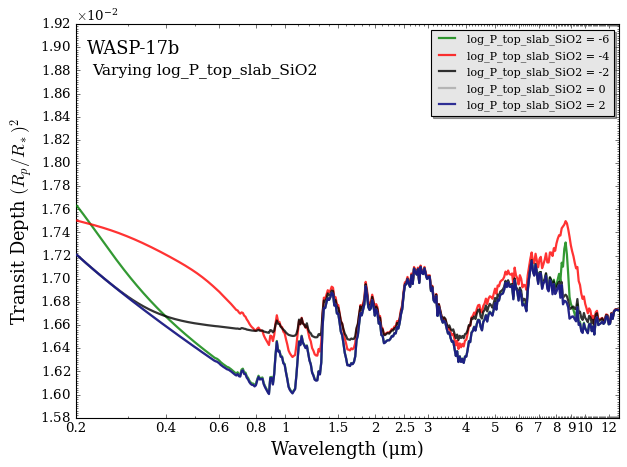

In [34]:
param_name = 'log_P_top_slab_SiO2'
vary_list = [-6,-4,-2,0,2]

vary_one_parameter(model_slab, planet, star, param_name, vary_list,
                   wl, opac_sio2, P, P_ref, R_p_ref, PT_params, log_X_params, cloud_params)

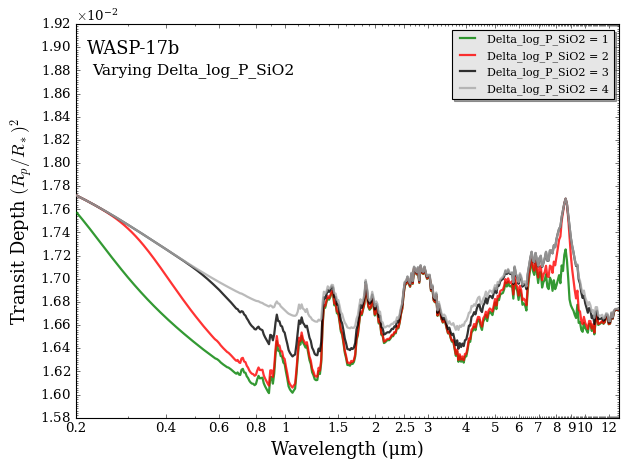

In [35]:
param_name = 'Delta_log_P_SiO2'
vary_list = [1,2,3,4]

vary_one_parameter(model_slab, planet, star, param_name, vary_list,
                   wl, opac_sio2, P, P_ref, R_p_ref, PT_params, log_X_params, cloud_params)

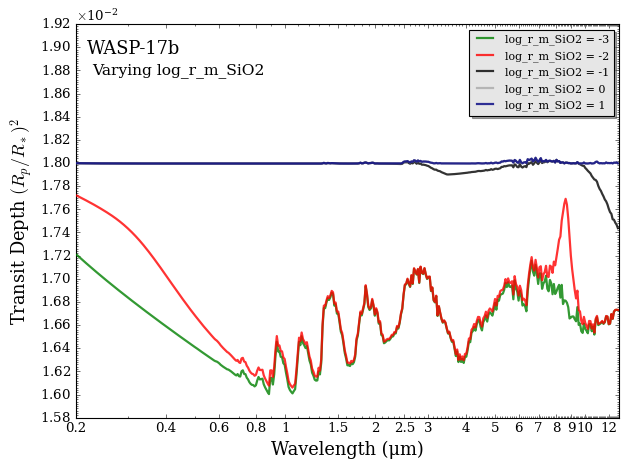

In [36]:
param_name = 'log_r_m_SiO2'
vary_list = [-3,-2,-1,0,1]

vary_one_parameter(model_slab, planet, star, param_name, vary_list,
                   wl, opac_sio2, P, P_ref, R_p_ref, PT_params, log_X_params, cloud_params)

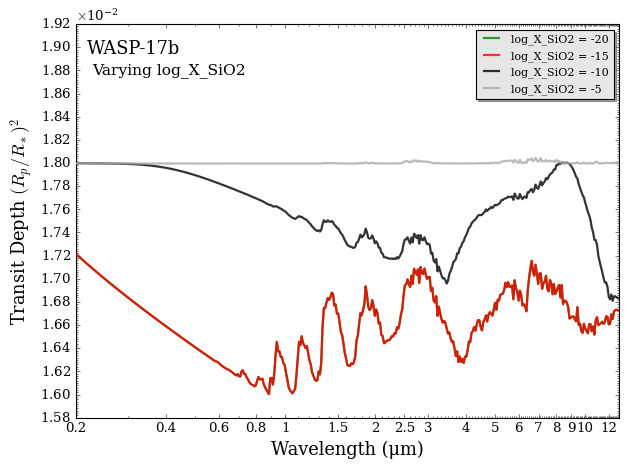

In [37]:
param_name = 'log_X_SiO2'
vary_list = [-20,-15,-10,-5]

vary_one_parameter(model_slab, planet, star, param_name, vary_list,
                   wl, opac_sio2, P, P_ref, R_p_ref, PT_params, log_X_params, cloud_params)